# Speed Check

In [2]:
import numpy as np

In [2]:
a1 = []

for i in range(10000000):
    a1.append(i)

In [3]:
a2 = []

for i in range(10000000,20000000):
    a2.append(i)

### Sum operation on a list

In [4]:
import time

start = time.time()
a3 = []

for i in range(len(a1)):
    a3.append(a1[i]+a2[i])

print(time.time()-start)

0.7213499546051025


### Sum operation in numpy

In [5]:
a4 = np.arange(10000000)
a5 = np.arange(10000000,20000000)

In [6]:
start = time.time()

a4+a5

print(time.time()-start)

0.021750688552856445


### Numpy is better for data analysis because

1. takes less time to do the same task
2. have flexbility in datatype storage unit like int32, int16
3. much convenient to do the complex task by simple syntax 

# Fancy Indexing

Fancy Indexing is a powerful feature in NumPy that allows you to access or modify specific elements of an array using arrays of indices (integers) or boolean masks.

### Integer Array Indexing
Instead of using scalars (like arr[5]) or slices (like arr[1:5]), you pass a list or an array of integers to pick out specific elements.

- **1D Arrays**: Pass a list of the exact positions you want.

    - *Example*: arr[[0, 2, 4]] returns the 1st, 3rd, and 5th elements.

- **2D Arrays**: Pass two lists representing the row and column coordinates.

    - **Syntax**: arr[[row1, row2], [col1, col2]]

    - *Result*: This returns elements at coordinates (row1, col1) and (row2, col2).

In [4]:
a1 = np.arange(24).reshape(4,6)
a1

array([[ 0,  1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10, 11],
       [12, 13, 14, 15, 16, 17],
       [18, 19, 20, 21, 22, 23]])

In [5]:
# Extract 1st, 3rd, 4th rows

a1[[0,2,3],:]

array([[ 0,  1,  2,  3,  4,  5],
       [12, 13, 14, 15, 16, 17],
       [18, 19, 20, 21, 22, 23]])

In [6]:
# Extract 2nd, 5th, 6th columns

a1[:, [1,4,5]]

array([[ 1,  4,  5],
       [ 7, 10, 11],
       [13, 16, 17],
       [19, 22, 23]])

In [7]:
# Extract 0 and 7

a1[[0,1],[0,1]]

array([0, 7])

In [9]:
# Extract 14, 22, 23

a1[[2,3,3],[2,4,5]]

array([14, 22, 23])

### Boolean Indexing (Masking)
Boolean indexing allows you to select elements based on a logical condition rather than their position.

- **How it works**: You create a "mask" (an array of True and False) by applying a condition to the array.

- **Syntax**: arr[condition]

- **Use Case**: Filtering data, such as removing outliers or selecting values within a specific range.

In [10]:
a1 = np.random.randint(1,100,72).reshape(8,9)
a1

array([[30, 17,  5, 94, 40, 50, 34, 10, 35],
       [92, 66, 89, 36, 38, 74, 54, 11, 13],
       [53,  9, 27,  4, 27, 37, 53, 30, 38],
       [64, 14, 44, 71, 70, 42, 52, 84, 63],
       [58, 12, 63, 34, 44, 30, 84, 82, 98],
       [ 2, 34,  5, 61, 49, 92, 58, 86, 81],
       [87, 27, 93, 51, 95, 17, 46, 16, 34],
       [16, 37, 36, 57, 87, 76, 61, 94, 77]])

In [11]:
# Extract where numbers are greater than 60 and even

mask =  (a1 > 60) & (a1 % 2 == 0)
mask

array([[False, False, False,  True, False, False, False, False, False],
       [ True,  True, False, False, False,  True, False, False, False],
       [False, False, False, False, False, False, False, False, False],
       [ True, False, False, False,  True, False, False,  True, False],
       [False, False, False, False, False, False,  True,  True,  True],
       [False, False, False, False, False,  True, False,  True, False],
       [False, False, False, False, False, False, False, False, False],
       [False, False, False, False, False,  True, False,  True, False]])

In [12]:
a1[mask]

array([94, 92, 66, 74, 64, 70, 84, 84, 82, 98, 92, 86, 76, 94])

In [13]:
# Extract where numbers are either greater than 60 or even

mask = (a1 > 60) | (a1 % 2 == 0)
mask

array([[ True, False, False,  True,  True,  True,  True,  True, False],
       [ True,  True,  True,  True,  True,  True,  True, False, False],
       [False, False, False,  True, False, False, False,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True, False,  True, False,  True,  True,  True,  True],
       [ True, False,  True, False,  True, False,  True,  True,  True],
       [ True, False,  True, False,  True,  True,  True,  True,  True]])

In [14]:
a1[mask]

array([30, 94, 40, 50, 34, 10, 92, 66, 89, 36, 38, 74, 54,  4, 30, 38, 64,
       14, 44, 71, 70, 42, 52, 84, 63, 58, 12, 63, 34, 44, 30, 84, 82, 98,
        2, 34, 61, 92, 58, 86, 81, 87, 93, 95, 46, 16, 34, 16, 36, 87, 76,
       61, 94, 77])

# Broadcasting

The term broadcasting describes how NumPy treats arrays with different shapes during arithmetic operations.

The smaller array is “broadcast” across the larger array so that they have compatible shapes.

# Broadcasting Rules

**1. Make the two arrays have the same number of dimensions.**<br>
- If the numbers of dimensions of the two arrays are different, add new dimensions with size 1 to the head of the array with the smaller dimension.<br>

**2. Make each dimension of the two arrays the same size.**<br>
- If the sizes of each dimension of the two arrays do not match, dimensions with size 1 are stretched to the size of the other array.
- If there is a dimension whose size is not 1 in either of the two arrays, it cannot be broadcasted, and an error is raised.


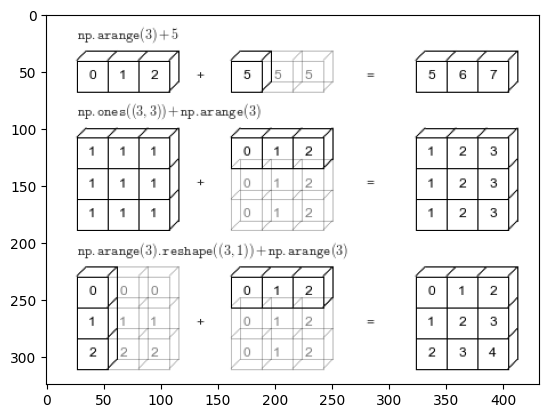

In [19]:
import cv2
import matplotlib.pyplot as plt

file_path = 'Broadcasting.png'

img = cv2.imread(file_path)
image = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.show()

In [22]:
a1 = np.arange(18).reshape(3,6)
a2 = np.arange(5)
a2.shape

(5,)

In order to perform the arithimetic operation between a1 and a2, we have to use the broadcast technique. 

It is done by  firstly, converting the shape of a2 from (5,) to (1,5), then, checking whether the shapes of both numpy arrays are same or not.

Since, it is not same (3,6) != (1,5), then apply, second broadcasting rule which is to stretch the 1 to the shape of the larger numpy array, so, a2 shape now become (3,5).

Since, it is not equal then it throws an error while performing any kind of arithmetic operations.

In [25]:
a1 + a2 

ValueError: operands could not be broadcast together with shapes (3,6) (5,) 

In [27]:
a1 = np.arange(12).reshape(3,4)
a2 = np.arange(4)

Here, firstly, dimension of a2 changes from (4,) -> (1,4)
Then, strech 1 to 3
It makes a2 shape = (3,4)

so, here we can perform any kind of arithmetic operations

In [28]:
a1+a2

array([[ 0,  2,  4,  6],
       [ 4,  6,  8, 10],
       [ 8, 10, 12, 14]])

In [29]:
a1-a2

array([[0, 0, 0, 0],
       [4, 4, 4, 4],
       [8, 8, 8, 8]])

In [30]:
a1*a2

array([[ 0,  1,  4,  9],
       [ 0,  5, 12, 21],
       [ 0,  9, 20, 33]])

In [31]:
a1 = np.arange(16).reshape(4,4)
a2 = np.arange(4).reshape(2,2)

Since dimension of a1, a2 is same, so checking if there is 1 present then, we can streych it, but since there is no 1, brocasting failed, and raises an error while doing arithmetic operations.

In [32]:
a1+a2

ValueError: operands could not be broadcast together with shapes (4,4) (2,2) 

# Working with Mathematical formula

1. Sigmoid Function

    $S(x) = \frac{1}{1 + e^{-x}}$


In [33]:
def sigmoid(array):
    return 1/(1+np.exp((-1)*array))

In [34]:
a = np.arange(20)

In [37]:
sigmoid(a)

array([0.5       , 0.73105858, 0.88079708, 0.95257413, 0.98201379,
       0.99330715, 0.99752738, 0.99908895, 0.99966465, 0.99987661,
       0.9999546 , 0.9999833 , 0.99999386, 0.99999774, 0.99999917,
       0.99999969, 0.99999989, 0.99999996, 0.99999998, 0.99999999])

In [36]:
np.round(sigmoid(a), decimals=2)

array([0.5 , 0.73, 0.88, 0.95, 0.98, 0.99, 1.  , 1.  , 1.  , 1.  , 1.  ,
       1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  ])

In [38]:
b= np.arange(20).reshape(4,-1)

In [39]:
sigmoid(b)

array([[0.5       , 0.73105858, 0.88079708, 0.95257413, 0.98201379],
       [0.99330715, 0.99752738, 0.99908895, 0.99966465, 0.99987661],
       [0.9999546 , 0.9999833 , 0.99999386, 0.99999774, 0.99999917],
       [0.99999969, 0.99999989, 0.99999996, 0.99999998, 0.99999999]])

In [40]:
np.round(sigmoid(b), decimals=2)

array([[0.5 , 0.73, 0.88, 0.95, 0.98],
       [0.99, 1.  , 1.  , 1.  , 1.  ],
       [1.  , 1.  , 1.  , 1.  , 1.  ],
       [1.  , 1.  , 1.  , 1.  , 1.  ]])

2. Mean Square Error
    $$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

In [ ]:
a1 = np.random.randint(1,100,25).reshape(5,5)
p1 = np.random.randint(1,100,25).reshape(5,5)

In [41]:
def mse(actual, predicted):
    return np.mean((actual-predicted)**2)

In [48]:
a1

array([[ 8, 88, 14, 56, 85],
       [13, 29, 57, 61, 41],
       [94, 86,  1, 12, 69],
       [57, 45, 60, 63, 74],
       [15, 63, 36, 25, 72]])

In [49]:
p1

array([[18, 71,  6, 84, 99],
       [27, 84, 56,  2, 87],
       [73, 16, 69,  8, 87],
       [51, 52,  2, 14, 86],
       [77,  4, 15, 90, 35]])

In [43]:
mse(a1,p1)

np.float64(1596.44)

3. Binary Cross Entropy
    $$BCE = -\frac{1}{n} \sum_{i=1}^{n} [y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i)]$$

In [46]:
def bce(actual, predicted):
    return np.mean(-1 * ((actual * np.log(predicted))+ ((1-actual) * np.log(1-predicted))))

In [57]:
a1 = np.linspace(0.1, 0.95, 25).reshape(5,5)
p1 = np.linspace(0.1, 0.95, 25).reshape(5,5)

In [58]:
a1

array([[0.1       , 0.13541667, 0.17083333, 0.20625   , 0.24166667],
       [0.27708333, 0.3125    , 0.34791667, 0.38333333, 0.41875   ],
       [0.45416667, 0.48958333, 0.525     , 0.56041667, 0.59583333],
       [0.63125   , 0.66666667, 0.70208333, 0.7375    , 0.77291667],
       [0.80833333, 0.84375   , 0.87916667, 0.91458333, 0.95      ]])

In [59]:
p1

array([[0.1       , 0.13541667, 0.17083333, 0.20625   , 0.24166667],
       [0.27708333, 0.3125    , 0.34791667, 0.38333333, 0.41875   ],
       [0.45416667, 0.48958333, 0.525     , 0.56041667, 0.59583333],
       [0.63125   , 0.66666667, 0.70208333, 0.7375    , 0.77291667],
       [0.80833333, 0.84375   , 0.87916667, 0.91458333, 0.95      ]])

In [60]:
bce(a1,p1)

np.float64(0.5469686414890794)

# nan values

In [62]:
a1 = np.array([1,2,3,4,5,np.nan,7,8])
a1

array([ 1.,  2.,  3.,  4.,  5., nan,  7.,  8.])

Remove nan from the numpy array

In [64]:
mask = np.isnan(a1)
mask

array([False, False, False, False, False,  True, False, False])

~ represents negation

In [66]:
a1[~mask]

array([1., 2., 3., 4., 5., 7., 8.])

# Working with Graphs

In [68]:
import matplotlib.pyplot as plt

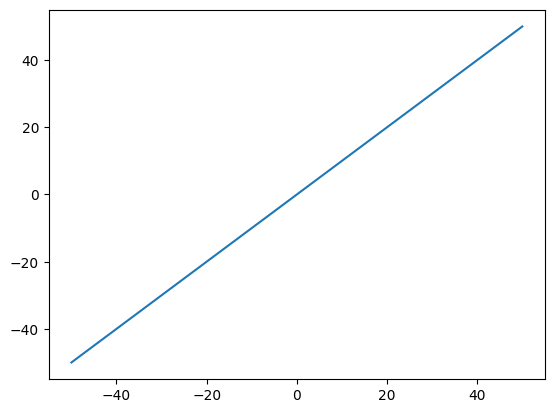

In [69]:
# y=x

x = np.linspace(-50,50,100)
y = x

plt.plot(x,y)

/var/folders/94/2_5s7zqj0cqd50nz6b9khlxh0000gp/T/ipykernel_97822/1723804289.py:3: RuntimeWarning: invalid value encountered in log
  y = x * np.log(x)


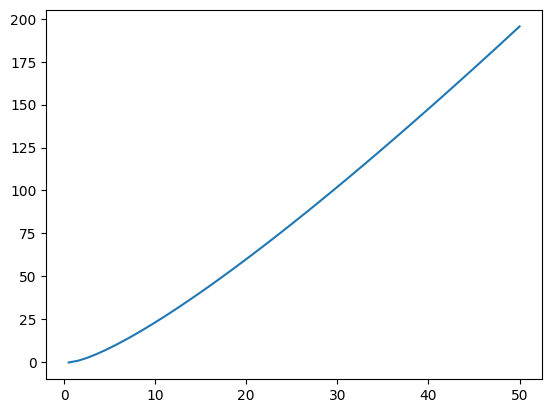

In [70]:
# y = xlogx

y = x * np.log(x)

plt.plot(x,y)